In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as cx

In [2]:
estaciones_sel = pd.read_csv("../export/estaciones-seleccionadas.csv")
extraccion = pd.read_csv("../export/extraccion_20260827-174348.csv", sep=";", low_memory=False)

print(estaciones_sel.shape, extraccion.shape)
estaciones_sel.head()

(383, 10) (400505, 35)


,nombre_programa,id_programa,estacion,id_estacion,latitud,longitud,id_tipo_punto,tip_pun_est_descripcion,id_matriz,nombre_matriz
0,Agua Arroyo Grande del Norte DCA,40,XGRN100.S,100626,-32.905795,-57.413038,1,SUPERFICIE,6,Aguas superficiales
1,Agua Arroyo Grande del Sur DCA,39,XGRS100.S,100625,-33.248939,-57.261889,1,SUPERFICIE,6,Aguas superficiales
2,Agua Laguna Merin DCA,10,XYAG010.S,100286,-32.533749,-53.446399,1,SUPERFICIE,6,Aguas superficiales
3,Agua Laguna Merin DCA,10,XCEB005.S,100295,-33.829494,-54.768973,1,SUPERFICIE,6,Aguas superficiales
4,Agua Laguna Merin DCA,10,XCEB030.S,100292,-33.158403,-53.651085,1,SUPERFICIE,6,Aguas superficiales


In [3]:
sel_ids = set(estaciones_sel["id_estacion"])
ext_ids = set(extraccion["id_estacion"])

print(f"Estaciones en catalogo (seleccionadas): {len(sel_ids)}")
print(f"Estaciones unicas con muestras (extraccion): {len(ext_ids)}")
print(f"En ambos (overlap): {len(sel_ids & ext_ids)}")
print(f"Solo en seleccionadas (sin muestras en esta extraccion): {len(sel_ids - ext_ids)}")
print(f"Solo en extraccion (sin geometria en el catalogo): {len(ext_ids - sel_ids)}")

Estaciones en catalogo (seleccionadas): 383
Estaciones unicas con muestras (extraccion): 372
En ambos (overlap): 372
Solo en seleccionadas (sin muestras en esta extraccion): 11
Solo en extraccion (sin geometria en el catalogo): 0


In [4]:
estaciones_gdf = gpd.GeoDataFrame(
    estaciones_sel,
    geometry=gpd.points_from_xy(estaciones_sel["longitud"], estaciones_sel["latitud"]),
    crs="EPSG:4326",
)
estaciones_gdf.head()

,nombre_programa,id_programa,estacion,id_estacion,latitud,longitud,id_tipo_punto,tip_pun_est_descripcion,id_matriz,nombre_matriz,geometry
0,Agua Arroyo Grande del Norte DCA,40,XGRN100.S,100626,-32.905795,-57.413038,1,SUPERFICIE,6,Aguas superficiales,POINT (-57.41304 -32.9058)
1,Agua Arroyo Grande del Sur DCA,39,XGRS100.S,100625,-33.248939,-57.261889,1,SUPERFICIE,6,Aguas superficiales,POINT (-57.26189 -33.24894)
2,Agua Laguna Merin DCA,10,XYAG010.S,100286,-32.533749,-53.446399,1,SUPERFICIE,6,Aguas superficiales,POINT (-53.4464 -32.53375)
3,Agua Laguna Merin DCA,10,XCEB005.S,100295,-33.829494,-54.768973,1,SUPERFICIE,6,Aguas superficiales,POINT (-54.76897 -33.82949)
4,Agua Laguna Merin DCA,10,XCEB030.S,100292,-33.158403,-53.651085,1,SUPERFICIE,6,Aguas superficiales,POINT (-53.65108 -33.1584)


In [5]:
columnas_compartidas = [c for c in extraccion.columns if c in estaciones_gdf.columns and c != "id_estacion"]

registros = estaciones_gdf.merge(
    extraccion.drop(columns=columnas_compartidas),
    on="id_estacion",
    how="inner",
)

print(registros.shape)
registros.head()

(400505, 39)


,nombre_programa,id_programa,estacion,id_estacion,latitud,longitud,id_tipo_punto,tip_pun_est_descripcion,id_matriz,nombre_matriz,...,param,nombre_clave,parametro,grupo,id_unidad,uni_nombre,valor_original,limite_deteccion,limite_cuantificacion,valor_transformado
0,Agua Arroyo Grande del Norte DCA,40,XGRN100.S,100626,-32.905795,-57.413038,1,SUPERFICIE,6,Aguas superficiales,...,AlcT,AlcT,Alcalinidad Total,Físico-Químicos Generales,1026,mg CaCO3/L,170.000000000,NaN,10.000000000,170.000000000
1,Agua Arroyo Grande del Norte DCA,40,XGRN100.S,100626,-32.905795,-57.413038,1,SUPERFICIE,6,Aguas superficiales,...,Cond,Conduc,Conductividad,Físico-Químicos Generales,1022,µS/cm,206.000000000,NaN,NaN,206.000000000
2,Agua Arroyo Grande del Norte DCA,40,XGRN100.S,100626,-32.905795,-57.413038,1,SUPERFICIE,6,Aguas superficiales,...,DrzT,DurezaT,Dureza total,Físico-Químicos Generales,1026,mg CaCO3/L,130.000000000,NaN,NaN,130.000000000
3,Agua Arroyo Grande del Norte DCA,40,XGRN100.S,100626,-32.905795,-57.413038,1,SUPERFICIE,6,Aguas superficiales,...,OD,OD,Oxigeno disuelto,Físico-Químicos Generales,7,mg/L,10.800000000,NaN,NaN,10.800000000
4,Agua Arroyo Grande del Norte DCA,40,XGRN100.S,100626,-32.905795,-57.413038,1,SUPERFICIE,6,Aguas superficiales,...,pH,pH,Potencial de hidrogeno (pH),Físico-Químicos Generales,1044,sin unid,7.880000000,NaN,NaN,7.880000000


In [6]:
estaciones_join = registros.drop_duplicates(subset="id_estacion")[
    ["id_estacion", "estacion", "nombre_programa", "tip_pun_est_descripcion", "geometry"]
].reset_index(drop=True)

print(f"Estaciones unicas en el join: {len(estaciones_join)}")
estaciones_join.head()

Estaciones unicas en el join: 372


,id_estacion,estacion,nombre_programa,tip_pun_est_descripcion,geometry
0,100626,XGRN100.S,Agua Arroyo Grande del Norte DCA,SUPERFICIE,POINT (-57.41304 -32.9058)
1,100625,XGRS100.S,Agua Arroyo Grande del Sur DCA,SUPERFICIE,POINT (-57.26189 -33.24894)
2,100286,XYAG010.S,Agua Laguna Merin DCA,SUPERFICIE,POINT (-53.4464 -32.53375)
3,100295,XCEB005.S,Agua Laguna Merin DCA,SUPERFICIE,POINT (-54.76897 -33.82949)
4,100292,XCEB030.S,Agua Laguna Merin DCA,SUPERFICIE,POINT (-53.65108 -33.1584)


In [7]:
registros.to_file("../export/joins/estaciones_extraccion.geojson", driver="GeoJSON")
estaciones_join.to_file("../export/joins/estaciones_extraccion_puntos.geojson", driver="GeoJSON")

In [8]:
estaciones_geojson = gpd.read_file("../export/estaciones.geojson")

# Coincidencia de coordenadas EXACTAS (redondeando a 6 decimales, ~11cm,
# solo para tolerar ruido de punto flotante, no diferencias reales)
DECIMALES = 6

a = estaciones_join.assign(
    lon_r=estaciones_join.geometry.x.round(DECIMALES),
    lat_r=estaciones_join.geometry.y.round(DECIMALES),
)
b = estaciones_geojson.assign(
    lon_r=estaciones_geojson.geometry.x.round(DECIMALES),
    lat_r=estaciones_geojson.geometry.y.round(DECIMALES),
)

coincidencias = a.merge(
    b[["nombre", "type", "lon_r", "lat_r"]],
    on=["lon_r", "lat_r"],
    how="inner",
)

print(f"Puntos con coordenadas exactamente iguales: {len(coincidencias)}")
coincidencias[["estacion", "nombre", "type"]].sort_values("type")

Puntos con coordenadas exactamente iguales: 248


,estacion,nombre,type
0,XGRN100.S,URY00194,GEMS
157,NE71A.S,URY00205,GEMS
158,RB52A.S,URY00203,GEMS
159,NE64A.S,URY00204,GEMS
160,NE84A.S,URY00211,GEMS
...,...,...,...
88,XCAH010.S,URY00049,GEMS
89,XTAC020.S,URY00171,GEMS
90,XTAH013.S,URY00249,GEMS
77,XCOL005.S,URY00250,GEMS


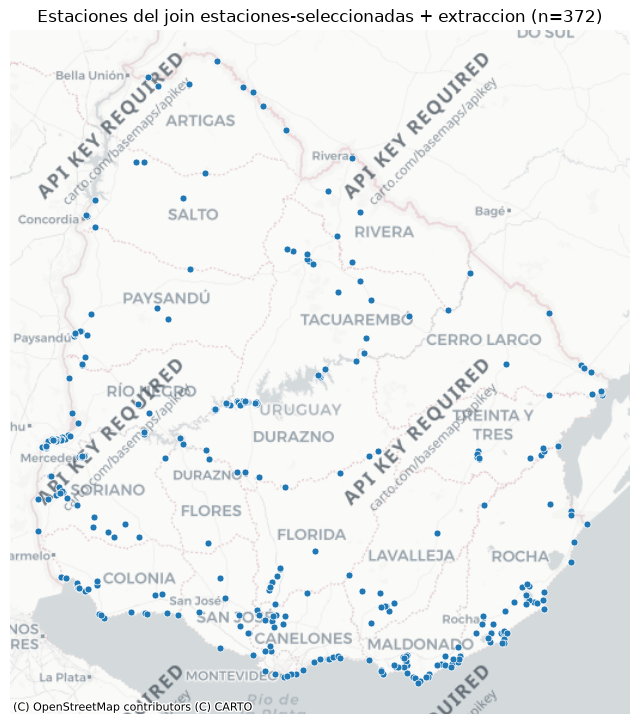

In [9]:
gdf_mapa = estaciones_join.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(8, 10))
gdf_mapa.plot(ax=ax, markersize=25, color="tab:blue", edgecolor="white", linewidth=0.5)
cx.add_basemap(ax, source=cx.providers.CartoDB.Positron)
ax.set_axis_off()
ax.set_title(f"Estaciones del join estaciones-seleccionadas + extraccion (n={len(gdf_mapa)})")
plt.show()

In [10]:
print("=== Resumen ===")
print(f"Estaciones en catalogo (seleccionadas): {len(sel_ids)}")
print(f"Estaciones con muestras en la extraccion: {len(ext_ids)}")
print(f"Estaciones en el join (inner): {len(estaciones_join)}")
print(f"Registros totales en el join (estacion x muestra x parametro): {len(registros)}")
print(f"Estaciones del join con coordenadas exactamente iguales a estaciones.geojson: {len(coincidencias)}")

=== Resumen ===
Estaciones en catalogo (seleccionadas): 383
Estaciones con muestras en la extraccion: 372
Estaciones en el join (inner): 372
Registros totales en el join (estacion x muestra x parametro): 400505
Estaciones del join con coordenadas exactamente iguales a estaciones.geojson: 248
